# Commodity Prices Dataset Analysis

Kaggle Dataset link : https://www.kaggle.com/datasets/debashish311601/commodity-prices

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("data/commodity_futures.csv")

In [3]:
df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6092 entries, 0 to 6091
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6092 non-null   str    
 1   NATURAL GAS          6083 non-null   float64
 2   GOLD                 6082 non-null   float64
 3   WTI CRUDE            6083 non-null   float64
 4   BRENT CRUDE          6090 non-null   float64
 5   SOYBEANS             6083 non-null   float64
 6   CORN                 6084 non-null   float64
 7   COPPER               6083 non-null   float64
 8   SILVER               6079 non-null   float64
 9   LOW SULPHUR GAS OIL  6090 non-null   float64
 10  LIVE CATTLE          6084 non-null   float64
 11  SOYBEAN OIL          6079 non-null   float64
 12  ALUMINIUM            6045 non-null   float64
 13  SOYBEAN MEAL         6082 non-null   float64
 14  ZINC                 6046 non-null   float64
 15  ULS DIESEL           6083 non-null   float64
 16 

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values("Date").reset_index(drop=True)

In [7]:
df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,1237.50,NaN,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,1215.00,67.78,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,1209.25,66.55,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,1212.00,66.28,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,1209.25,64.75,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96


In [8]:
# Create Year & Month for seasonal/group analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [9]:
df.head()

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON,Year,Month
0,2000-01-03,NaN,NaN,NaN,NaN,456.50,200.75,NaN,NaN,NaN,...,8446.0,247.50,6.10,NaN,116.50,55.975,274.25,51.07,2000,1
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.8480,5.375,213.50,...,8314.0,247.25,5.77,NaN,116.25,55.625,274.00,50.73,2000,1
2,2000-01-05,2.168,282.1,24.91,23.73,469.25,203.00,0.8565,5.210,213.00,...,8307.0,249.75,5.81,NaN,118.60,55.075,276.25,51.56,2000,1
3,2000-01-06,2.196,282.4,24.78,23.62,468.00,203.75,0.8530,5.167,211.25,...,8252.0,248.50,5.77,NaN,116.85,55.175,275.00,52.08,2000,1
4,2000-01-07,2.173,282.9,24.22,23.09,471.50,207.00,0.8540,5.195,205.25,...,8174.0,251.75,5.84,NaN,114.15,55.625,277.75,53.96,2000,1


In [10]:
# Quick check of missing values
print(df.isna().sum())

Date                      0
NATURAL GAS               9
GOLD                     10
WTI CRUDE                 9
BRENT CRUDE               2
SOYBEANS                  9
CORN                      8
COPPER                    9
SILVER                   13
LOW SULPHUR GAS OIL       2
LIVE CATTLE               8
SOYBEAN OIL              13
ALUMINIUM                47
SOYBEAN MEAL             10
ZINC                     46
ULS DIESEL                9
NICKEL                   46
WHEAT                    14
SUGAR                     9
GASOLINE               1491
COFFEE                   12
LEAN HOGS                 8
HRW WHEAT                14
COTTON                   13
Year                      0
Month                     0
dtype: int64


In [11]:
# Forward fill missing values
df_ffill = df.ffill()

In [12]:
# Check again
print(df_ffill.isna().sum())

Date                      0
NATURAL GAS               1
GOLD                      1
WTI CRUDE                 1
BRENT CRUDE               1
SOYBEANS                  0
CORN                      0
COPPER                    1
SILVER                    1
LOW SULPHUR GAS OIL       1
LIVE CATTLE               0
SOYBEAN OIL               0
ALUMINIUM                 1
SOYBEAN MEAL              0
ZINC                      0
ULS DIESEL                1
NICKEL                    0
WHEAT                     0
SUGAR                     0
GASOLINE               1483
COFFEE                    0
LEAN HOGS                 0
HRW WHEAT                 0
COTTON                    0
Year                      0
Month                     0
dtype: int64


In [13]:
df_clean = df.ffill().bfill()

In [14]:
# Check again
print(df_clean.isna().sum())

Date                   0
NATURAL GAS            0
GOLD                   0
WTI CRUDE              0
BRENT CRUDE            0
SOYBEANS               0
CORN                   0
COPPER                 0
SILVER                 0
LOW SULPHUR GAS OIL    0
LIVE CATTLE            0
SOYBEAN OIL            0
ALUMINIUM              0
SOYBEAN MEAL           0
ZINC                   0
ULS DIESEL             0
NICKEL                 0
WHEAT                  0
SUGAR                  0
GASOLINE               0
COFFEE                 0
LEAN HOGS              0
HRW WHEAT              0
COTTON                 0
Year                   0
Month                  0
dtype: int64


In [15]:
# Price Trends of Commodities (Descriptive)
# Metals

In [16]:
df_clean.head(2)

,Date,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,...,NICKEL,WHEAT,SUGAR,GASOLINE,COFFEE,LEAN HOGS,HRW WHEAT,COTTON,Year,Month
0,2000-01-03,2.176,283.7,25.55,24.39,456.50,200.75,0.848,5.375,213.5,...,8446.0,247.50,6.10,188.88,116.50,55.975,274.25,51.07,2000,1
1,2000-01-04,2.176,283.7,25.55,24.39,464.25,203.00,0.848,5.375,213.5,...,8314.0,247.25,5.77,188.88,116.25,55.625,274.00,50.73,2000,1


In [17]:
df_clean.columns.to_list()

['Date',
 'NATURAL GAS',
 'GOLD',
 'WTI CRUDE',
 'BRENT CRUDE',
 'SOYBEANS',
 'CORN',
 'COPPER',
 'SILVER',
 'LOW SULPHUR GAS OIL',
 'LIVE CATTLE',
 'SOYBEAN OIL',
 'ALUMINIUM',
 'SOYBEAN MEAL',
 'ZINC',
 'ULS DIESEL',
 'NICKEL',
 'WHEAT',
 'SUGAR',
 'GASOLINE',
 'COFFEE',
 'LEAN HOGS',
 'HRW WHEAT',
 'COTTON',
 'Year',
 'Month']

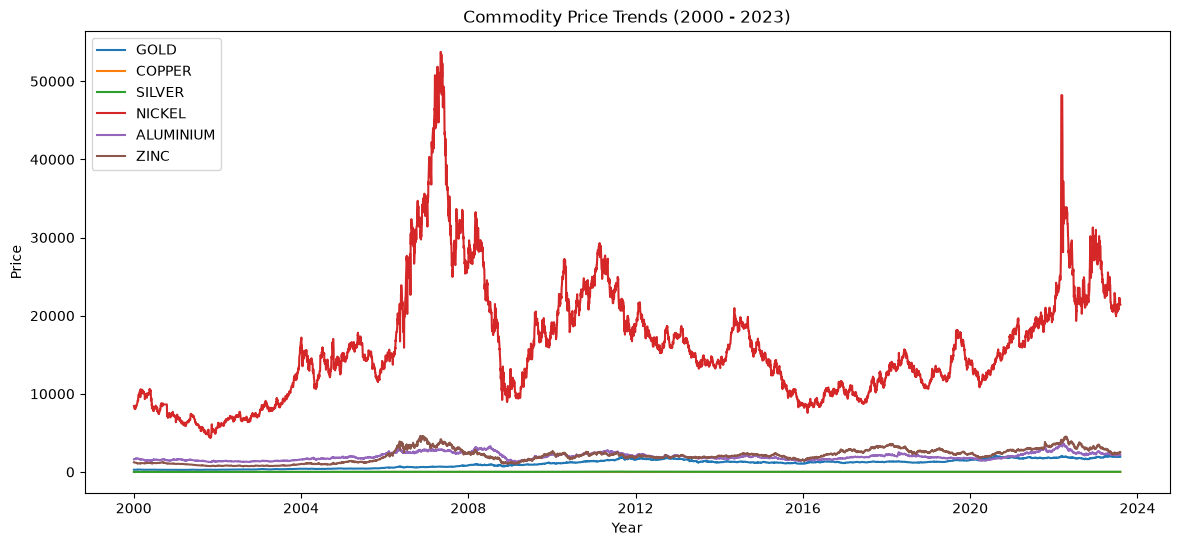

In [18]:
metals = ["GOLD", "COPPER", "SILVER", "NICKEL", "ALUMINIUM", "ZINC"]
plt.figure(figsize=(14,6))
for col in metals :
    plt.plot(df_clean['Date'], df_clean[col], label=col)
plt.title("Commodity Price Trends (2000 - 2023)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

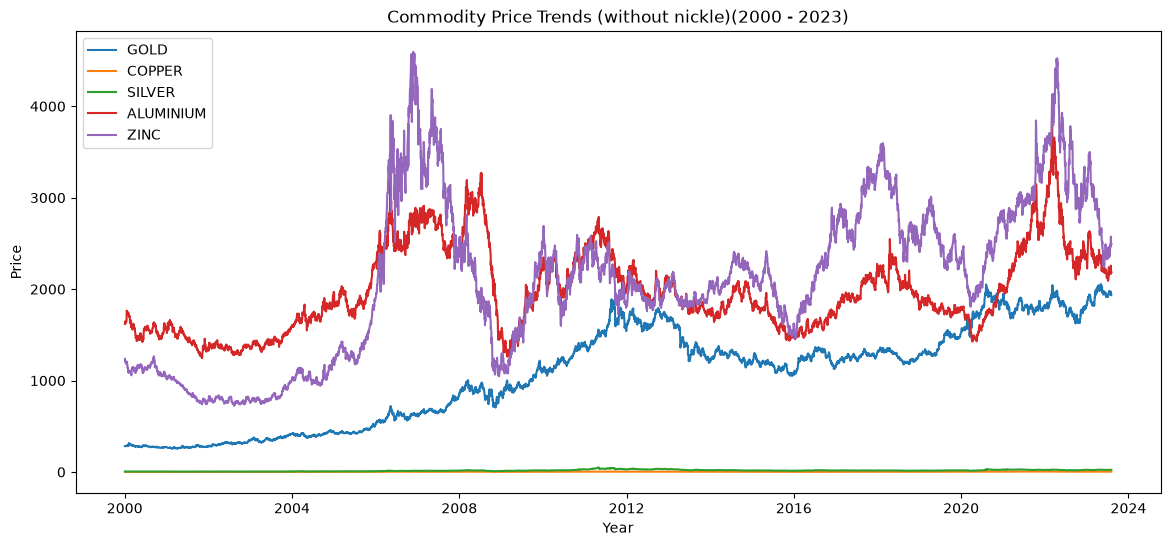

In [19]:
metals = ["GOLD", "COPPER", "SILVER", "ALUMINIUM", "ZINC"]
plt.figure(figsize=(14,6))
for col in metals :
    plt.plot(df_clean['Date'], df_clean[col], label=col)
plt.title("Commodity Price Trends (without nickle)(2000 - 2023)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

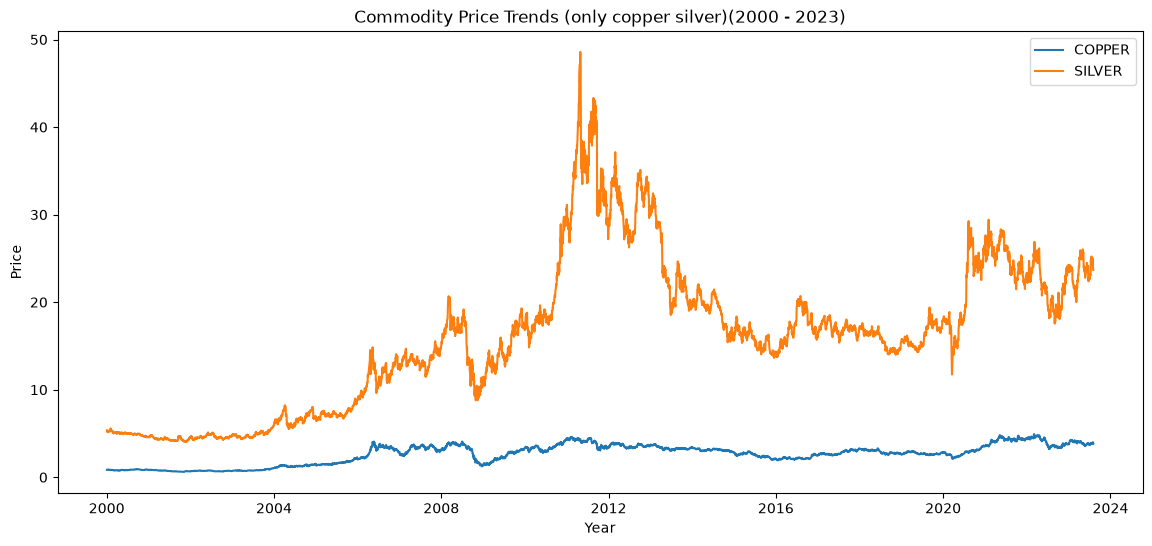

In [20]:
metals = ["COPPER", "SILVER"]
plt.figure(figsize=(14,6))
for col in metals :
    plt.plot(df_clean['Date'], df_clean[col], label=col)
plt.title("Commodity Price Trends (only copper silver)(2000 - 2023)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

In [21]:
# spike / fluctuations --> volatlity
# sharp spike / rapid fluctuations --> [zinc, nickel]